In [1]:
p = 34
p

34

In [2]:
import sys, os

In [3]:
%pwd

'd:\\Projects\\portfolio\\01-bias-audit\\research'

In [4]:
os.chdir('../')

In [5]:
%pwd

'd:\\Projects\\portfolio\\01-bias-audit'

In [6]:
# ── Cell 1 — imports & setup ─────────────────────────────────────────

import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from config.configuration import load_config
from src.constants import (
    MODEL_DIR,
    TOKENIZER_DIR,
    PROCESSED_DATA_FILE,
    METRICS_DIR,
    TARGET_COLUMN,
    PROTECTED_ATTRIBUTES,
)
from src.utils import load_dataframe, load_json
from src import get_logger

logger = get_logger("research.evaluation")
CONFIG = load_config()

print("✅ Imports successful")
print(f"   Model dir       : {MODEL_DIR}")
print(f"   Processed data  : {PROCESSED_DATA_FILE}")
print(f"   Protected attrs : {PROTECTED_ATTRIBUTES}")
print(f"   Thresholds:")
print(f"     Demographic parity  : {CONFIG.thresholds.demographic_parity}")
print(f"     Disparate impact    : {CONFIG.thresholds.disparate_impact}")
print(f"     Equal opportunity   : {CONFIG.thresholds.equal_opportunity}")

✅ Imports successful
   Model dir       : outputs\model
   Processed data  : data\processed\clean.csv
   Protected attrs : ['sex', 'race', 'marital.status']
   Thresholds:
     Demographic parity  : 0.1
     Disparate impact    : 0.8
     Equal opportunity   : 0.1


In [7]:
# ── Cell 2 — load model & tokenizer ──────────────────────────────────
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

try:
    if not Path(MODEL_DIR).exists():
        raise FileNotFoundError(
            f"Model not found at {MODEL_DIR}\n"
            "  → Run prepare_base_model.ipynb first"
        )

    tokenizer = AutoTokenizer.from_pretrained(str(TOKENIZER_DIR))
    model     = AutoModelForSequenceClassification.from_pretrained(str(MODEL_DIR))
    model     = model.to(device)
    model.eval()

    print(f"Tokenizer loaded ✅")
    print(f"Model loaded     ✅  ({sum(p.numel() for p in model.parameters()):,} params)")

except FileNotFoundError as e:
    logger.error(str(e))
    print(f"\n❌ {e}")
except OSError as e:
    logger.error(f"Could not load model: {e}")
    raise

d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 1442.22it/s]

Tokenizer loaded ✅
Model loaded     ✅  (66,955,010 params)


In [8]:
# ── Cell 3 — load processed data ─────────────────────────────────────
try:
    if not Path(PROCESSED_DATA_FILE).exists():
        raise FileNotFoundError(
            f"Processed data not found: {PROCESSED_DATA_FILE}\n"
            "  → Run data_ingestion.ipynb first"
        )

    df = load_dataframe(str(PROCESSED_DATA_FILE))
    print(f"Data loaded ✅  shape: {df.shape}")
    print(f"\nClass distribution:")
    vc = df[TARGET_COLUMN].value_counts()
    for val, count in vc.items():
        print(f"  {val} : {count:>6,}  ({count/len(df)*100:.1f}%)")
    df.head()

except FileNotFoundError as e:
    logger.error(str(e))
    print(f"\n❌ {e}")

[2026-05-06 14:13:13] INFO src.utils.common - DataFrame loaded: data\processed\clean.csv — shape: (30162, 15)
Data loaded ✅  shape: (30162, 15)

Class distribution:
  0 : 22,654  (75.1%)
  1 :  7,508  (24.9%)


In [9]:
# ── Cell 4 — build text inputs ────────────────────────────────────────
def build_texts(df: pd.DataFrame) -> list[str]:
    return df.apply(
        lambda r: (
            f"age {r['age']}, education {r['education']}, "
            f"occupation {r['occupation']}, "
            f"hours {r['hours.per.week']}, "
            f"sex {r['sex']}, race {r['race']}"
        ),
        axis=1,
    ).tolist()

texts = build_texts(df)

# sanity check a few samples
print("Sample text inputs:\n")
for t in texts[:3]:
    print(f"  {t}")

print(f"\nTotal texts : {len(texts):,}")

Sample text inputs:

  age 82, education HS-grad, occupation Exec-managerial, hours 18, sex Female, race White
  age 54, education 7th-8th, occupation Machine-op-inspct, hours 40, sex Female, race White
  age 41, education Some-college, occupation Prof-specialty, hours 40, sex Female, race White

Total texts : 30,162


In [10]:
# ── Cell 5 — run batch inference ─────────────────────────────────────
from torch.utils.data import DataLoader, Dataset

class InferenceDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length):
        self.encodings = tokenizer(
            texts,
            max_length=max_length,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
    def __len__(self):
        return self.encodings["input_ids"].shape[0]
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

try:
    dataset    = InferenceDataset(texts, tokenizer, CONFIG.model.max_length)
    dataloader = DataLoader(dataset, batch_size=CONFIG.model.batch_size, shuffle=False)

    all_preds, all_probs = [], []

    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            batch   = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            probs   = F.softmax(outputs.logits, dim=-1)
            preds   = torch.argmax(probs, dim=-1)
            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs[:, 1].cpu().tolist())

            if (i + 1) % 20 == 0:
                print(f"  Batches processed: {i+1} / {len(dataloader)}")

    df["prediction"]  = all_preds
    df["prob_gt50k"]  = all_probs

    print(f"\nInference complete ✅")
    print(f"  Rows predicted       : {len(all_preds):,}")
    print(f"  Predicted >50K       : {sum(all_preds):,}  ({sum(all_preds)/len(all_preds)*100:.1f}%)")
    print(f"  Avg confidence >50K  : {np.mean(all_probs):.4f}")

except RuntimeError as e:
    logger.error(f"Inference failed — try reducing batch_size in config: {e}")
    print(f"\n❌ RuntimeError: {e}")
except Exception as e:
    logger.exception(f"Unexpected error during inference: {e}")
    raise

  Batches processed: 20 / 943
  Batches processed: 40 / 943
  Batches processed: 60 / 943
  Batches processed: 80 / 943
  Batches processed: 100 / 943
  Batches processed: 120 / 943
  Batches processed: 140 / 943
  Batches processed: 160 / 943
  Batches processed: 180 / 943
  Batches processed: 200 / 943
  Batches processed: 220 / 943
  Batches processed: 240 / 943
  Batches processed: 260 / 943
  Batches processed: 280 / 943
  Batches processed: 300 / 943
  Batches processed: 320 / 943
  Batches processed: 340 / 943
  Batches processed: 360 / 943
  Batches processed: 380 / 943
  Batches processed: 400 / 943
  Batches processed: 420 / 943
  Batches processed: 440 / 943
  Batches processed: 460 / 943
  Batches processed: 480 / 943
  Batches processed: 500 / 943
  Batches processed: 520 / 943
  Batches processed: 540 / 943
  Batches processed: 560 / 943
  Batches processed: 580 / 943
  Batches processed: 600 / 943
  Batches processed: 620 / 943
  Batches processed: 640 / 943
  Batches pr

Classification Report:

              precision    recall  f1-score   support

       <=50K       0.75      0.98      0.85     22654
        >50K       0.20      0.01      0.02      7508

    accuracy                           0.74     30162
   macro avg       0.48      0.50      0.44     30162
weighted avg       0.61      0.74      0.65     30162

ROC-AUC          : 0.5151
Average Precision : 0.2491


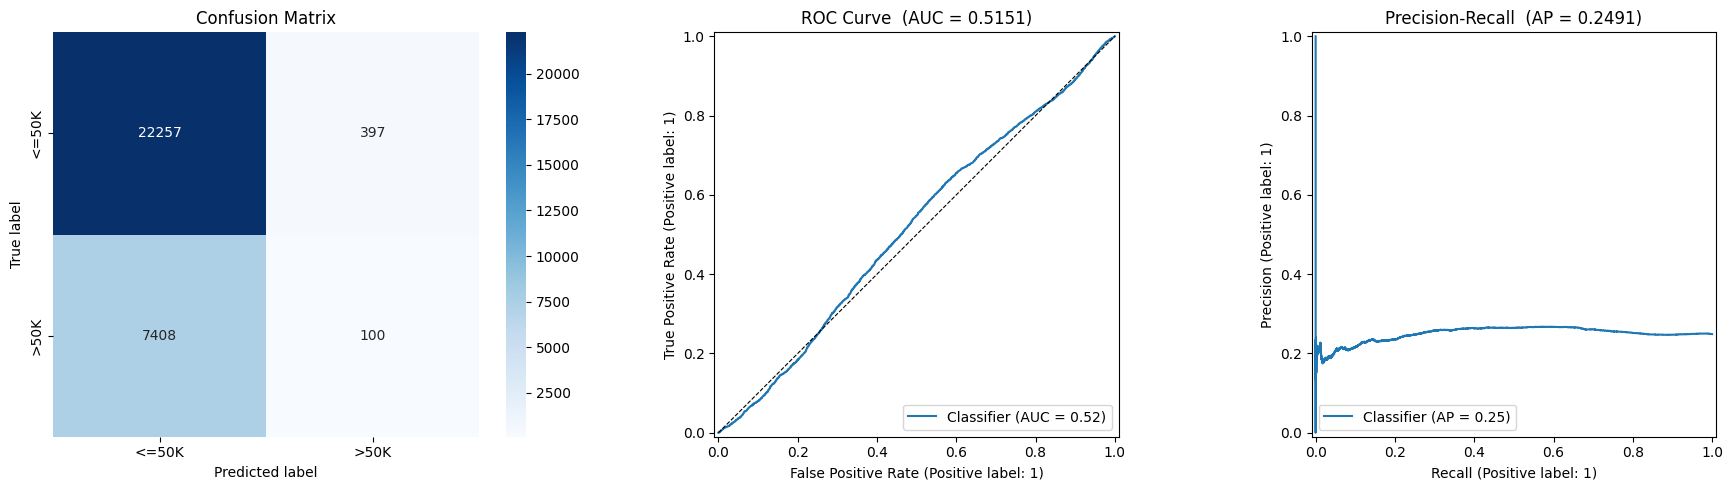

In [11]:
# ── Cell 6 — overall classification metrics ───────────────────────────
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

try:
    y_true = df[TARGET_COLUMN].tolist()
    y_pred = df["prediction"].tolist()
    y_prob = df["prob_gt50k"].tolist()

    print("Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=["<=50K", ">50K"]))

    roc_auc = roc_auc_score(y_true, y_prob)
    avg_pr  = average_precision_score(y_true, y_prob)
    print(f"ROC-AUC          : {roc_auc:.4f}")
    print(f"Average Precision : {avg_pr:.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
        xticklabels=["<=50K", ">50K"],
        yticklabels=["<=50K", ">50K"],
    )
    axes[0].set_title("Confusion Matrix")
    axes[0].set_ylabel("True label")
    axes[0].set_xlabel("Predicted label")

    # ROC curve
    RocCurveDisplay.from_predictions(y_true, y_prob, ax=axes[1])
    axes[1].set_title(f"ROC Curve  (AUC = {roc_auc:.4f})")
    axes[1].plot([0, 1], [0, 1], "k--", linewidth=0.8)

    # precision-recall curve
    PrecisionRecallDisplay.from_predictions(y_true, y_prob, ax=axes[2])
    axes[2].set_title(f"Precision-Recall  (AP = {avg_pr:.4f})")

    plt.tight_layout()
    plt.show()

except Exception as e:
    logger.error(f"Metrics computation failed: {e}")
    raise

Demographic Parity  (threshold: gap <= 0.1)

  sex
    Female                              0.0227  (2.3%)
    Male                                0.0135  (1.3%)
    Max gap: 0.0092   ✅ PASS

  race
    Amer-Indian-Eskimo                  0.3077  (30.8%)
    Asian-Pac-Islander                  0.2525  (25.3%)
    Other                               0.1991  (19.9%)
    Black                               0.0064  (0.6%)
    White                               0.0046  (0.5%)
    Max gap: 0.3031   ⚠️  FAIL

  marital.status
    Married-spouse-absent               0.0351  (3.5%)
    Never-married                       0.0283  (2.8%)
    Married-civ-spouse                  0.0110  (1.1%)
    Widowed                             0.0097  (1.0%)
    Separated                           0.0096  (1.0%)
    Divorced                            0.0088  (0.9%)
    Married-AF-spouse                   0.0000  (0.0%)
    Max gap: 0.0351   ✅ PASS



C:\Users\rajve\AppData\Local\Temp\ipykernel_26856\4221914675.py:35: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


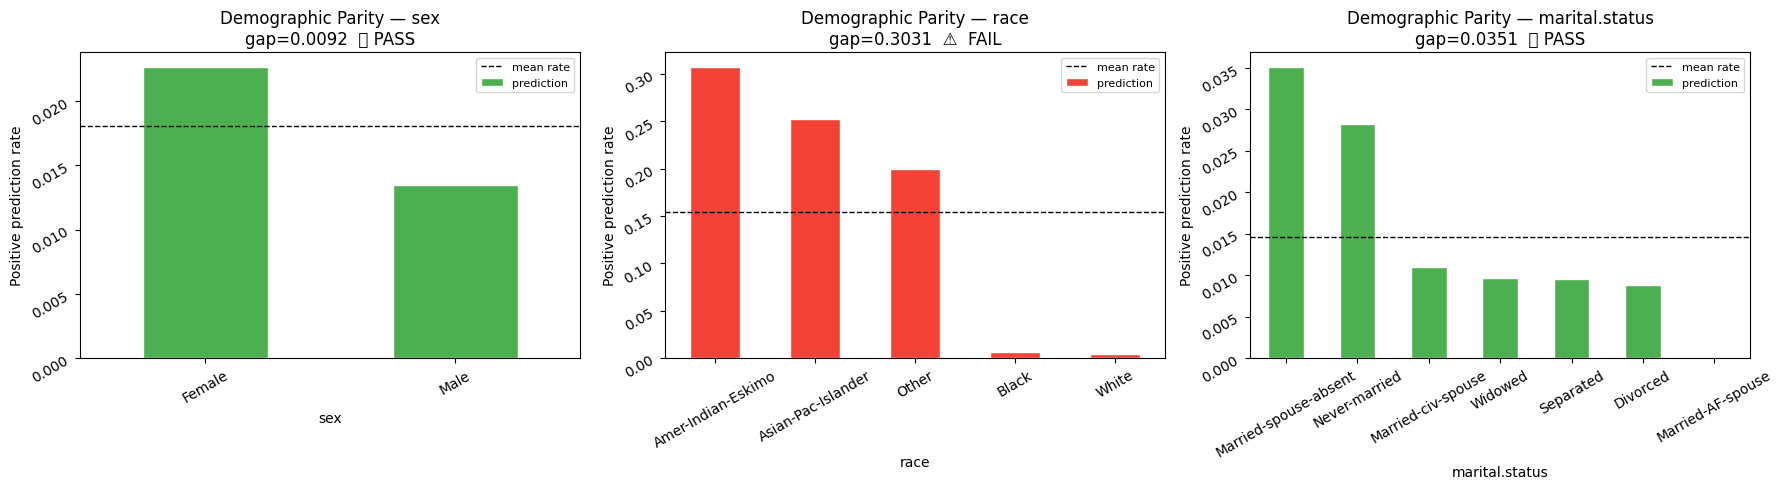

In [12]:
# ── Cell 7 — demographic parity ──────────────────────────────────────
try:
    fig, axes = plt.subplots(1, len(PROTECTED_ATTRIBUTES),
                              figsize=(6 * len(PROTECTED_ATTRIBUTES), 5))
    if len(PROTECTED_ATTRIBUTES) == 1:
        axes = [axes]

    threshold = CONFIG.thresholds.demographic_parity
    print(f"Demographic Parity  (threshold: gap <= {threshold})\n")

    for ax, attr in zip(axes, PROTECTED_ATTRIBUTES):
        if attr not in df.columns:
            print(f"  ⚠️  '{attr}' not in data — skipping")
            continue

        rates   = df.groupby(attr)["prediction"].mean().sort_values(ascending=False)
        max_gap = rates.max() - rates.min()
        passed  = max_gap <= threshold
        status  = "✅ PASS" if passed else "⚠️  FAIL"

        print(f"  {attr}")
        for group, rate in rates.items():
            print(f"    {str(group):<35} {rate:.4f}  ({rate*100:.1f}%)")
        print(f"    Max gap: {max_gap:.4f}   {status}\n")

        colors = ["#4CAF50" if passed else "#F44336"] * len(rates)
        rates.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
        ax.axhline(y=rates.mean(), color="black", linestyle="--",
                   linewidth=1, label="mean rate")
        ax.set_title(f"Demographic Parity — {attr}\ngap={max_gap:.4f}  {status}")
        ax.set_ylabel("Positive prediction rate")
        ax.tick_params(rotation=30)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

except Exception as e:
    logger.error(f"Demographic parity plot failed: {e}")
    raise

In [13]:
# ── Cell 8 — disparate impact ─────────────────────────────────────────
try:
    threshold = CONFIG.thresholds.disparate_impact
    print(f"Disparate Impact  (threshold: ratio >= {threshold}  |  80% rule)\n")

    for attr in PROTECTED_ATTRIBUTES:
        if attr not in df.columns:
            continue
        rates    = df.groupby(attr)["prediction"].mean()
        ratio    = rates.min() / rates.max() if rates.max() > 0 else 0
        passed   = ratio >= threshold
        status   = "✅ PASS" if passed else "⚠️  FAIL"
        print(f"  {attr}")
        print(f"    Min rate : {rates.min():.4f}  ({rates.idxmin()})")
        print(f"    Max rate : {rates.max():.4f}  ({rates.idxmax()})")
        print(f"    DI ratio : {ratio:.4f}   {status}\n")

except Exception as e:
    logger.error(f"Disparate impact computation failed: {e}")
    raise

Disparate Impact  (threshold: ratio >= 0.8  |  80% rule)

  sex
    Min rate : 0.0135  (Male)
    Max rate : 0.0227  (Female)
    DI ratio : 0.5946   ⚠️  FAIL

  race
    Min rate : 0.0046  (White)
    Max rate : 0.3077  (Amer-Indian-Eskimo)
    DI ratio : 0.0149   ⚠️  FAIL

  marital.status
    Min rate : 0.0000  (Married-AF-spouse)
    Max rate : 0.0351  (Married-spouse-absent)
    DI ratio : 0.0000   ⚠️  FAIL



Equal Opportunity  (threshold: TPR gap <= 0.1)

  sex
    Female                              TPR=0.0252
    Male                                TPR=0.0113
    Max TPR gap: 0.0139   ✅ PASS

  race
    Amer-Indian-Eskimo                  TPR=0.4412
    Asian-Pac-Islander                  TPR=0.2500
    Other                               TPR=0.0952
    Black                               TPR=0.0055
    White                               TPR=0.0028
    Max TPR gap: 0.4384   ⚠️  FAIL

  marital.status
    Married-spouse-absent               TPR=0.0645
    Never-married                       TPR=0.0298
    Widowed                             TPR=0.0250
    Separated                           TPR=0.0152
    Divorced                            TPR=0.0133
    Married-civ-spouse                  TPR=0.0117
    Married-AF-spouse                   TPR=0.0000
    Max TPR gap: 0.0645   ✅ PASS



C:\Users\rajve\AppData\Local\Temp\ipykernel_26856\3986135818.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


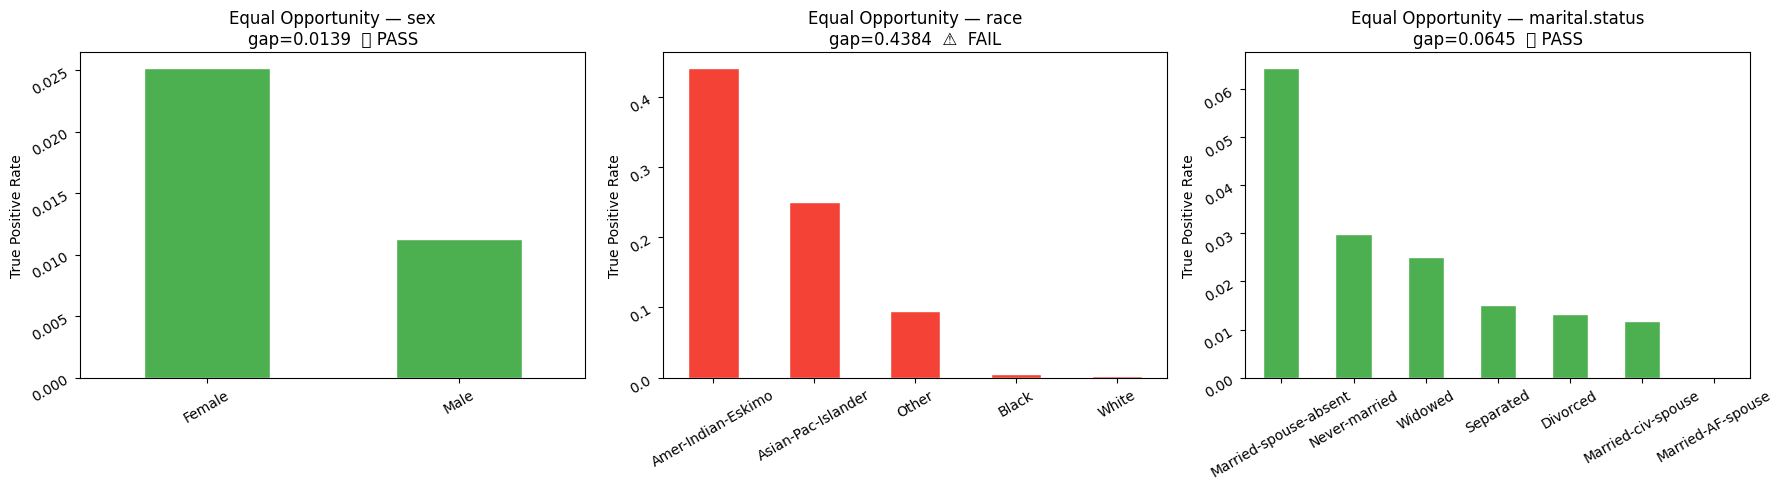

In [14]:
# ── Cell 9 — equal opportunity (TPR by group) ─────────────────────────
try:
    threshold = CONFIG.thresholds.equal_opportunity
    print(f"Equal Opportunity  (threshold: TPR gap <= {threshold})\n")

    fig, axes = plt.subplots(1, len(PROTECTED_ATTRIBUTES),
                              figsize=(6 * len(PROTECTED_ATTRIBUTES), 5))
    if len(PROTECTED_ATTRIBUTES) == 1:
        axes = [axes]

    for ax, attr in zip(axes, PROTECTED_ATTRIBUTES):
        if attr not in df.columns:
            continue

        tpr_by_group = {}
        for group, gdf in df.groupby(attr):
            pos = gdf[gdf[TARGET_COLUMN] == 1]
            tpr = pos["prediction"].mean() if len(pos) > 0 else 0.0
            tpr_by_group[str(group)] = round(tpr, 4)

        tpr_series = pd.Series(tpr_by_group).sort_values(ascending=False)
        max_gap    = tpr_series.max() - tpr_series.min()
        passed     = max_gap <= threshold
        status     = "✅ PASS" if passed else "⚠️  FAIL"

        print(f"  {attr}")
        for group, tpr in tpr_series.items():
            print(f"    {group:<35} TPR={tpr:.4f}")
        print(f"    Max TPR gap: {max_gap:.4f}   {status}\n")

        colors = ["#4CAF50" if passed else "#F44336"] * len(tpr_series)
        tpr_series.plot(kind="bar", ax=ax, color=colors, edgecolor="white")
        ax.set_title(f"Equal Opportunity — {attr}\ngap={max_gap:.4f}  {status}")
        ax.set_ylabel("True Positive Rate")
        ax.tick_params(rotation=30)

    plt.tight_layout()
    plt.show()

except Exception as e:
    logger.error(f"Equal opportunity plot failed: {e}")
    raise

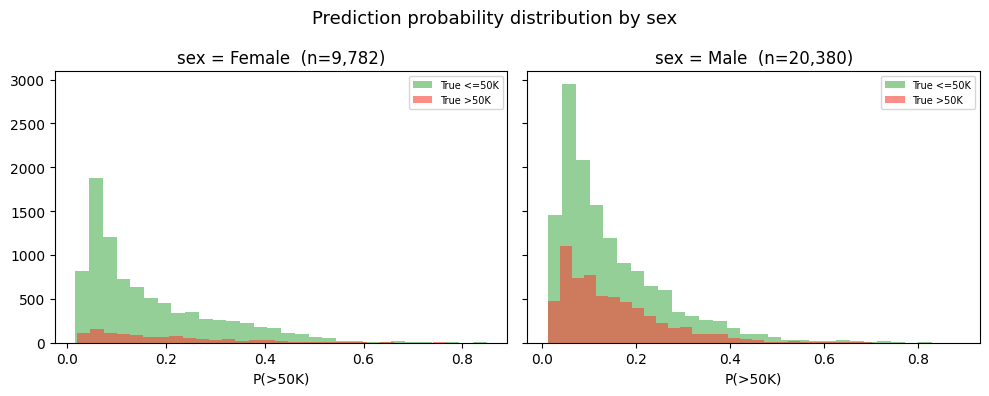

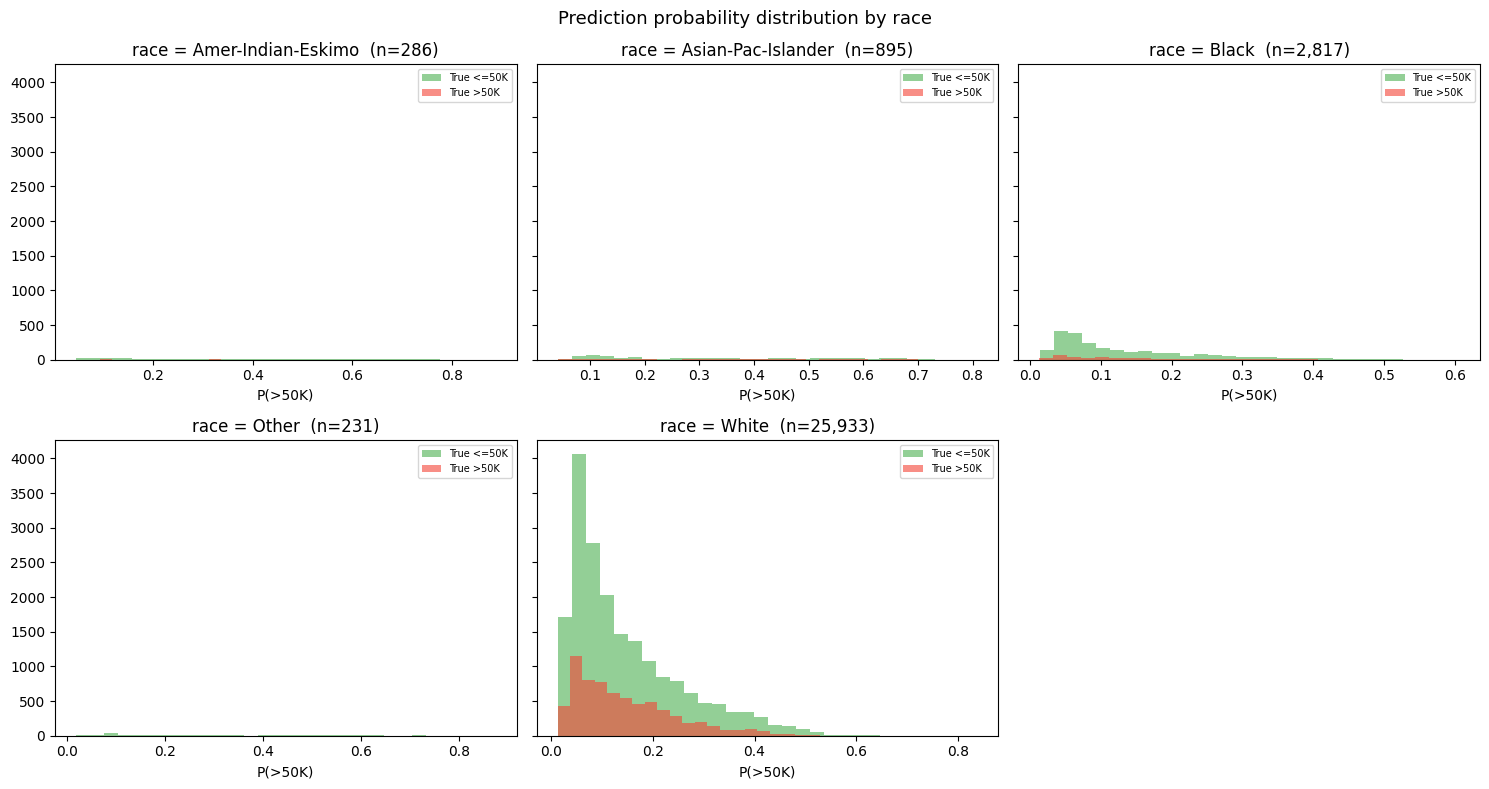

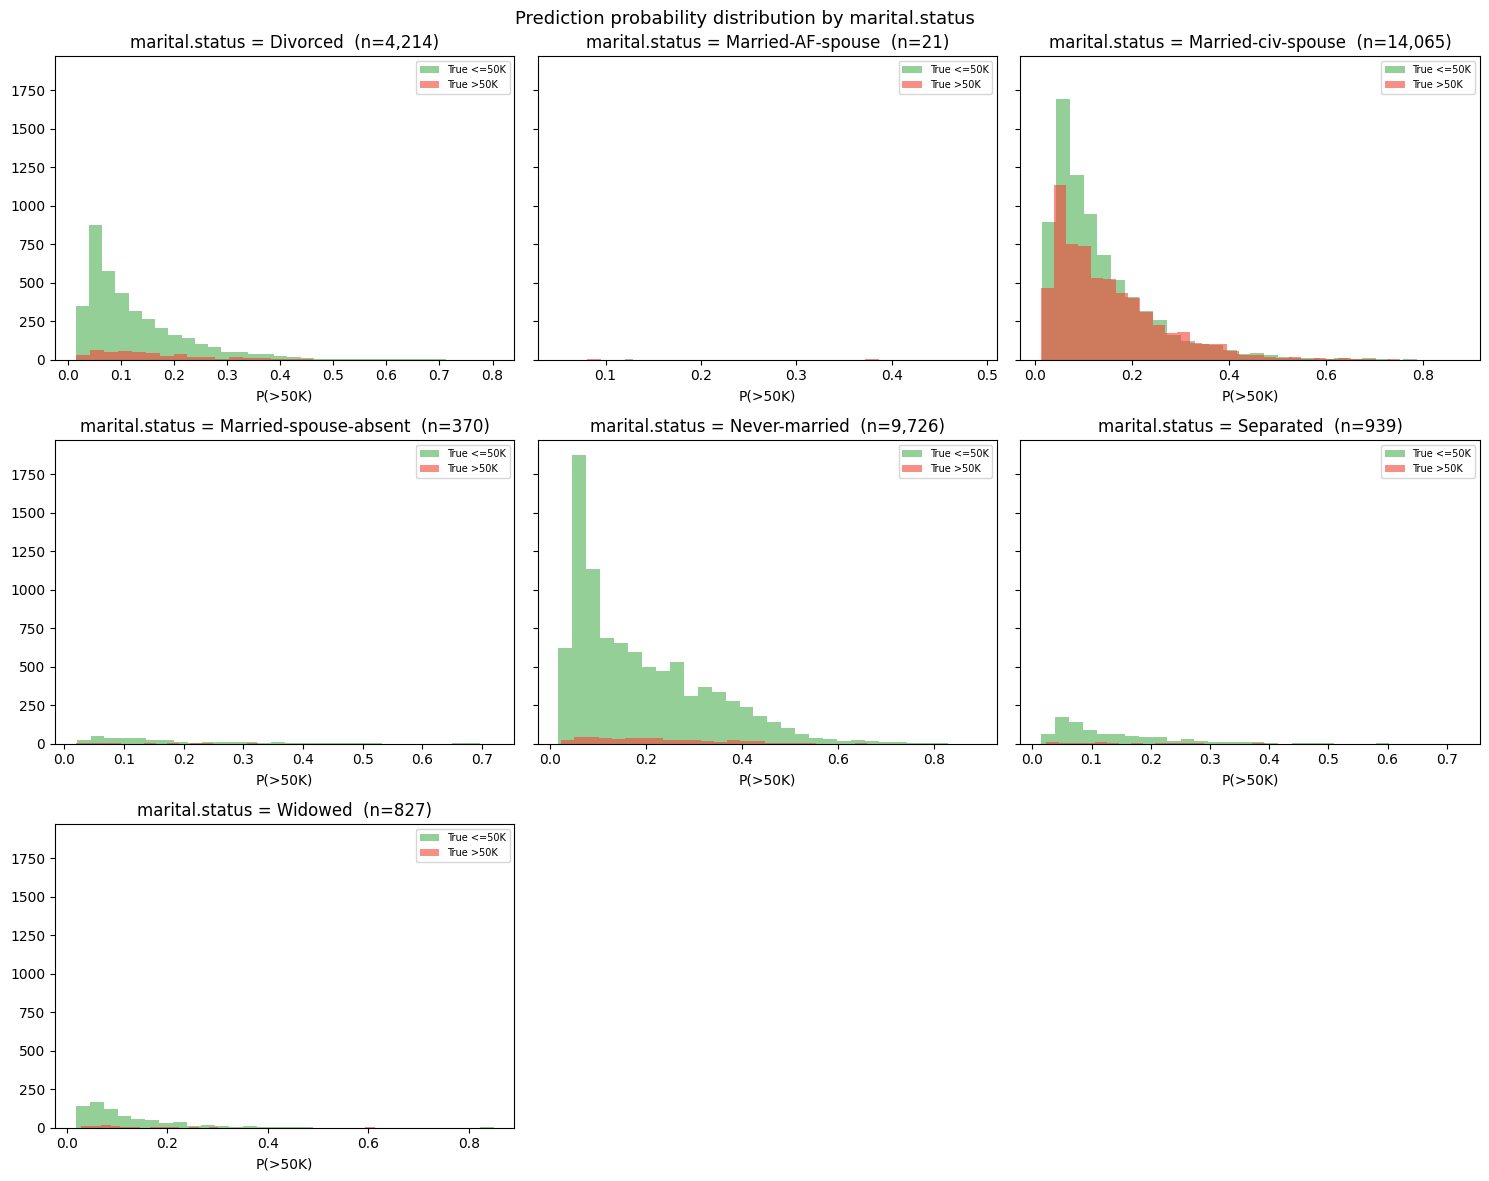

In [15]:
# ── Cell 10 — probability distribution by group ───────────────────────
try:
    for attr in PROTECTED_ATTRIBUTES:
        if attr not in df.columns:
            continue

        groups  = df[attr].unique()
        n_cols  = min(len(groups), 3)
        n_rows  = (len(groups) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols,
                                  figsize=(5 * n_cols, 4 * n_rows),
                                  sharey=True)
        axes = np.array(axes).flatten()

        for i, group in enumerate(sorted(groups)):
            gdf = df[df[attr] == group]
            axes[i].hist(
                gdf[gdf[TARGET_COLUMN] == 0]["prob_gt50k"],
                bins=30, alpha=0.6, label="True <=50K", color="#4CAF50"
            )
            axes[i].hist(
                gdf[gdf[TARGET_COLUMN] == 1]["prob_gt50k"],
                bins=30, alpha=0.6, label="True >50K", color="#F44336"
            )
            axes[i].set_title(f"{attr} = {group}  (n={len(gdf):,})")
            axes[i].set_xlabel("P(>50K)")
            axes[i].legend(fontsize=7)

        # hide unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].set_visible(False)

        fig.suptitle(f"Prediction probability distribution by {attr}", fontsize=13)
        plt.tight_layout()
        plt.show()

except Exception as e:
    logger.error(f"Distribution plot failed: {e}")
    raise

In [16]:
# ── Cell 11 — save metrics to disk ───────────────────────────────────
import json

try:
    METRICS_DIR.mkdir(parents=True, exist_ok=True)

    from sklearn.metrics import classification_report
    overall = {
        "accuracy":          round((pd.Series(y_true) == pd.Series(y_pred)).mean(), 4),
        "roc_auc":           round(roc_auc, 4),
        "average_precision": round(avg_pr, 4),
        "confusion_matrix":  confusion_matrix(y_true, y_pred).tolist(),
    }

    bias_results = {}
    for attr in PROTECTED_ATTRIBUTES:
        if attr not in df.columns:
            continue
        rates = df.groupby(attr)["prediction"].mean().round(4).to_dict()
        gap   = round(max(rates.values()) - min(rates.values()), 4)
        ratio = round(min(rates.values()) / max(rates.values()), 4)

        bias_results[attr] = {
            "demographic_parity": {
                "positive_rates": rates,
                "max_gap": gap,
                "passed": gap <= CONFIG.thresholds.demographic_parity,
            },
            "disparate_impact": {
                "ratio": ratio,
                "passed": ratio >= CONFIG.thresholds.disparate_impact,
            },
        }

    metrics_path     = METRICS_DIR / "metrics.json"
    bias_report_path = METRICS_DIR / "bias_report.json"

    metrics_path.write_text(json.dumps(overall, indent=4))
    bias_report_path.write_text(json.dumps(bias_results, indent=4))

    print(f"Metrics saved      → {metrics_path}")
    print(f"Bias report saved  → {bias_report_path}")
    logger.info("Metrics saved ✅")

except PermissionError as e:
    logger.error(f"Permission denied when saving: {e}")
    raise
except Exception as e:
    logger.exception(f"Failed to save metrics: {e}")
    raise

Metrics saved      → outputs\metrics\metrics.json
Bias report saved  → outputs\metrics\bias_report.json
[2026-05-06 15:25:02] INFO research.evaluation - Metrics saved ✅


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 63: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    ap

In [17]:
# ── Cell 12 — final summary ───────────────────────────────────────────
try:
    required_vars = {
        "df":     "df" in dir() and df is not None,
        "y_true": "y_true" in dir() and y_true is not None,
        "y_pred": "y_pred" in dir() and y_pred is not None,
        "roc_auc": "roc_auc" in dir(),
    }
    missing = [k for k, v in required_vars.items() if not v]
    if missing:
        raise NameError(
            f"Variables missing from memory: {missing}\n"
            "  → Re-run cells in order from Cell 3"
        )

    accuracy     = (pd.Series(y_true) == pd.Series(y_pred)).mean()
    bias_verdicts = {}

    for attr in PROTECTED_ATTRIBUTES:
        if attr not in df.columns:
            continue
        rates   = df.groupby(attr)["prediction"].mean()
        dp_gap  = round(rates.max() - rates.min(), 4)
        di_ratio= round(rates.min() / rates.max(), 4) if rates.max() > 0 else 0
        dp_pass = dp_gap  <= CONFIG.thresholds.demographic_parity
        di_pass = di_ratio >= CONFIG.thresholds.disparate_impact
        bias_verdicts[attr] = "✅ PASS" if (dp_pass and di_pass) else "⚠️  FAIL"

    all_passed = all("PASS" in v for v in bias_verdicts.values())

    print("=" * 55)
    print("   EVALUATION RESEARCH — SUMMARY")
    print("=" * 55)
    print(f"  Rows evaluated       : {len(df):,}")
    print(f"  Overall accuracy     : {accuracy:.4f}  ({accuracy*100:.1f}%)")
    print(f"  ROC-AUC              : {roc_auc:.4f}")
    print(f"  Average precision    : {avg_pr:.4f}")
    print()
    print("  Bias verdicts:")
    for attr, verdict in bias_verdicts.items():
        print(f"    {attr:<25} {verdict}")
    print()
    print(f"  Overall bias result  : {'✅ ALL CHECKS PASSED' if all_passed else '⚠️  BIAS DETECTED'}")
    print(f"  Metrics saved        : {METRICS_DIR / 'metrics.json'}")
    print(f"  Bias report saved    : {METRICS_DIR / 'bias_report.json'}")
    print("=" * 55)

    if not all_passed:
        failed = [a for a, v in bias_verdicts.items() if "FAIL" in v]
        logger.warning(f"Bias detected for attributes: {failed}")
    else:
        logger.info("All bias checks passed ✅")

    logger.info("Evaluation research complete ✅")
    print("\n  Next → check outputs/metrics/ for saved reports")

except NameError as e:
    logger.error(f"Variable missing: {e}")
    print(f"\n❌ NameError: {e}")
except KeyError as e:
    logger.error(f"Column missing: {e}")
    print(f"\n❌ KeyError: {e}  —  available: {df.columns.tolist()}")
except ZeroDivisionError as e:
    logger.error(f"Division by zero in bias metric — check group sizes: {e}")
    print(f"\n❌ ZeroDivisionError: {e}")
except Exception as e:
    logger.exception(f"Unexpected error in summary: {e}")
    print(f"\n❌ {type(e).__name__}: {e}")
    print("   Check logs/ for full traceback")

   EVALUATION RESEARCH — SUMMARY
  Rows evaluated       : 30,162
  Overall accuracy     : 0.7412  (74.1%)
  ROC-AUC              : 0.5151
  Average precision    : 0.2491

  Bias verdicts:
    sex                       ⚠️  FAIL
    race                      ⚠️  FAIL
    marital.status            ⚠️  FAIL

  Overall bias result  : ⚠️  BIAS DETECTED
  Metrics saved        : outputs\metrics\metrics.json
  Bias report saved    : outputs\metrics\bias_report.json
[2026-05-06 15:25:36] WARNING research.evaluation - Bias detected for attributes: ['sex', 'race', 'marital.status']
[2026-05-06 15:25:36] INFO research.evaluation - Evaluation research complete ✅

  Next → check outputs/metrics/ for saved reports


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\logging\__init__.py", line 1163, in emit
    stream.write(msg + self.terminator)
  File "C:\Users\rajve\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 78: character maps to <undefined>
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "d:\Projects\portfolio\01-bias-audit\.venv\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    ap